**-: Seasonal Agriculture Performance Analysis :-**

**Problem Statement:**

Agricultural activities are influenced by seasonal variations in environmental conditions,
farming practices, resource availability and market conditions. As a result, agricultural
performance may differ from one season to another.
However, raw agricultural data does not clearly explain how agricultural performance changes
across seasons or what patterns can be observed in different seasonal conditions.
The problem is to analyze the given agricultural dataset and investigate seasonal differences
in agricultural performance by identifying meaningful patterns, trends, relationships and
variations within the available data.

In [139]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
pd.options.display.float_format = '{:.2f}'.format

In [140]:
df = pd.read_csv('/content/seasonal_agriculture_performance_dataset.csv')
df

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40


In [141]:
df.shape

(4000, 28)

In [142]:
df.head()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.40,24.30,69.10,5.80,...,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.49,55.30
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.40,25.70,78.40,5.10,...,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.40,49.90
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.60,23.90,56.40,10.30,...,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.98,33.70
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.20,29.70,65.20,6.30,...,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.16,50.60
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.60,34.10,55.20,6.50,...,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.83,32.30


In [143]:
df.tail()

,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,...,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
3995,SF13996,Karnataka,Rajkot,Wheat,Kharif,4.72,865.40,27.30,51.40,6.30,...,0.74,0.51,2.41,22717,362917,54748,-308169,2016,1.20,45.20
3996,SF13997,Karnataka,Krishna,Chilli,Kharif,8.77,947.50,29.20,85.50,6.10,...,0.80,2.75,24.12,106459,496471,2567791,2071320,5351,4.51,59.70
3997,SF13998,Andhra Pradesh,Erode,Pulses,Zaid,10.47,80.00,35.40,68.50,8.60,...,0.99,0.62,6.49,66860,785632,433921,-351711,3392,1.91,29.20
3998,SF13999,Punjab,Warangal,Cotton,Kharif,1.73,475.00,28.20,61.70,6.40,...,0.98,1.35,2.34,75282,153904,176160,22256,1220,1.92,50.40
3999,SF14000,Punjab,Nashik,Wheat,Kharif,3.31,984.30,25.80,77.20,5.90,...,0.99,2.36,7.81,28812,263872,225022,-38850,1800,4.34,62.30


In [144]:
df.columns.to_list()

['Farm_ID',
 'State',
 'District',
 'Crop',
 'Season',
 'Farm_Area_Hectares',
 'Rainfall_mm',
 'Avg_Temperature_C',
 'Humidity_pct',
 'Sunlight_Hours_Day',
 'Soil_pH',
 'Soil_Moisture_pct',
 'Nitrogen_kg_ha',
 'Phosphorus_kg_ha',
 'Potassium_kg_ha',
 'Irrigation_Method',
 'Fertilizer_kg_ha',
 'Pesticide_Litre_ha',
 'Seed_Quality_Score',
 'Yield_Tonnes_Ha',
 'Production_Tonnes',
 'Market_Price_INR_Tonne',
 'Total_Cost_INR',
 'Revenue_INR',
 'Profit_INR',
 'Water_Used_m3',
 'Water_Efficiency_t_per_1000m3',
 'Disease_Pest_Risk_pct']

In [145]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   object 
 1   State                          4000 non-null   object 
 2   District                       4000 non-null   object 
 3   Crop                           4000 non-null   object 
 4   Season                         4000 non-null   object 
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   f

In [146]:
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.00,7.89,4.22,0.50,4.26,7.90,11.65,15.00
Rainfall_mm,3952.00,601.15,288.93,80.00,370.20,582.00,834.95,1395.20
Avg_Temperature_C,4000.00,26.82,3.82,16.20,23.90,26.90,29.60,39.70
Humidity_pct,4000.00,63.21,11.96,25.00,54.78,63.00,71.90,95.00
Sunlight_Hours_Day,4000.00,7.32,1.12,3.50,6.60,7.30,8.10,11.00
Soil_pH,4000.00,6.70,0.64,5.20,6.26,6.69,7.14,8.40
Soil_Moisture_pct,3960.00,26.51,6.71,8.00,21.70,26.40,31.30,47.00
Nitrogen_kg_ha,4000.00,120.25,31.22,40.00,98.50,120.10,141.22,220.00
Phosphorus_kg_ha,4000.00,57.78,17.02,15.00,46.20,57.50,69.40,120.00
Potassium_kg_ha,4000.00,104.76,27.74,30.00,86.20,105.10,123.60,200.00


In [147]:
from os import dup

duplicate_count = df.duplicated().sum()
print('Duplicate Rows',duplicate_count)

Duplicate Rows 0


In [148]:
df.isnull().sum().describe()

,0
count,28.00
mean,4.29
std,12.79
min,0.00
25%,0.00
50%,0.00
75%,0.00
max,48.00


In [149]:
for col in ['Rainfall_mm', 'Soil_Moisture_pct', 'Yield_Tonnes_Ha']:
    df[col] = df[col].fillna(df[col].median())
df_clean = df.copy()

print("Missing values after imputation:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after imputation:
Series([], dtype: int64)


In [150]:
categorical_columns = df.select_dtypes(include="object").columns

for col in categorical_columns:
    print(f"\n{col}:")
    print(df[col].nunique(), "unique values")
    print(df[col].dropna().unique()[:20])


Farm_ID:
4000 unique values
['SF10001' 'SF10002' 'SF10003' 'SF10004' 'SF10005' 'SF10006' 'SF10007'
 'SF10008' 'SF10009' 'SF10010' 'SF10011' 'SF10012' 'SF10013' 'SF10014'
 'SF10015' 'SF10016' 'SF10017' 'SF10018' 'SF10019' 'SF10020']

State:
8 unique values
['Andhra Pradesh' 'Maharashtra' 'Telangana' 'Karnataka' 'Gujarat'
 'Tamil Nadu' 'Punjab' 'Madhya Pradesh']

District:
10 unique values
['Rajkot' 'Nalgonda' 'Warangal' 'Indore' 'Ludhiana' 'Raichur' 'Guntur'
 'Krishna' 'Nashik' 'Erode']

Crop:
8 unique values
['Wheat' 'Maize' 'Pulses' 'Rice' 'Cotton' 'Chilli' 'Groundnut' 'Sugarcane']

Season:
3 unique values
['Kharif' 'Rabi' 'Zaid']

Irrigation_Method:
4 unique values
['Drip' 'Flood' 'Rainfed' 'Sprinkler']


In [151]:
numeric_columns = df.select_dtypes(include=[np.number]).columns

statistical_summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Std_Dev": df[numeric_columns].std(),
    "Min": df[numeric_columns].min(),
    "Max": df[numeric_columns].max()
})

statistical_summary.round(2)

,Mean,Median,Std_Dev,Min,Max
Farm_Area_Hectares,7.89,7.90,4.22,0.50,15.00
Rainfall_mm,600.92,582.00,287.19,80.00,1395.20
Avg_Temperature_C,26.82,26.90,3.82,16.20,39.70
Humidity_pct,63.21,63.00,11.96,25.00,95.00
Sunlight_Hours_Day,7.32,7.30,1.12,3.50,11.00
Soil_pH,6.70,6.69,0.64,5.20,8.40
Soil_Moisture_pct,26.51,26.40,6.68,8.00,47.00
Nitrogen_kg_ha,120.25,120.10,31.22,40.00,220.00
Phosphorus_kg_ha,57.78,57.50,17.02,15.00,120.00
Potassium_kg_ha,104.76,105.10,27.74,30.00,200.00


In [152]:
season_summary = df.groupby("Season")[numeric_columns].agg(["mean", "median", "std"])
season_summary.round(2)

Farm_Area_Hectares             Rainfall_mm                \
                     mean median  std        mean median    std   
Season                                                            
Kharif               7.94   8.18 4.28      849.20 853.10 183.69   
Rabi                 7.75   7.68 4.18      437.62 432.20 175.35   
Zaid                 8.09   8.09 4.16      304.65 288.20 157.24   

       Avg_Temperature_C             Humidity_pct  ... Profit_INR  \
                    mean median  std         mean  ...        std   
Season                                             ...              
Kharif             28.45  28.50 2.51        71.81  ...  611549.78   
Rabi               23.49  23.50 2.46        57.89  ...  489901.25   
Zaid               31.04  31.00 2.55        52.01  ...  436356.75   

       Water_Used_m3                 Water_Efficiency_t_per_1000m3         \
                mean  median     std                          mean median   
Season                                                                      
Kharif       6102.20 4469.00 5670.58                          5.89   3.28   
Rabi         5846.99 4292.00 5397.65                          5.19   2.74   
Zaid         6419.89 4805.00 5734.62                          4.41   2.30   

            Disease_Pest_Risk_pct               
        std                  mean median   std  
Season                                          
Kharif 9.83                 54.47  54.50 10.09  
Rabi   8.26                 40.48  40.60 10.10  
Zaid   6.93                 38.22  37.90  9.87  

[3 rows x 66 columns]

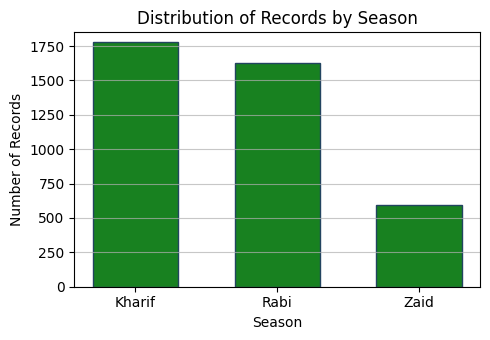

In [153]:
season_counts = df['Season'].value_counts()

plt.figure(figsize=(5, 3.5))
plt.bar(season_counts.index, season_counts.values, color='#188120', edgecolor='#224460', width=0.6)

plt.title('Distribution of Records by Season', fontsize=12)
plt.xlabel('Season', fontsize=10)
plt.ylabel('Number of Records', fontsize=10)
plt.grid(axis='y', linestyle='-', alpha=0.7)
plt.ylim(0, 1850)

plt.tight_layout()
plt.show()

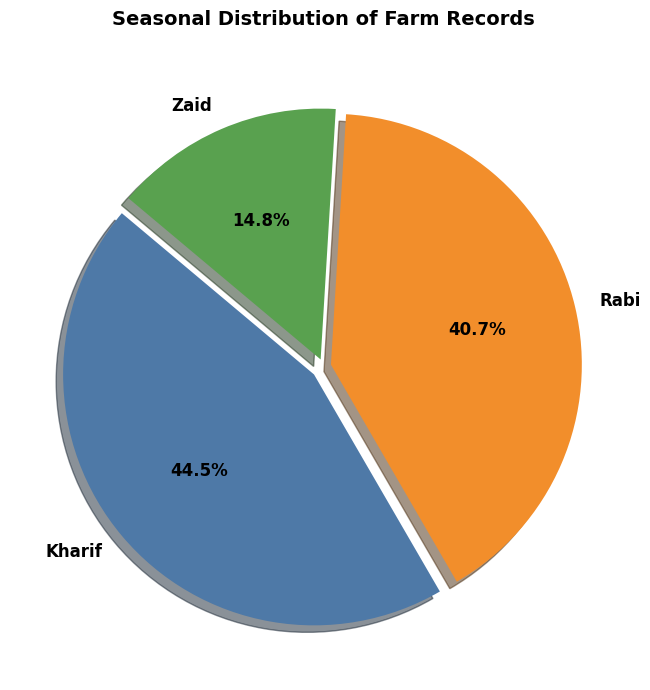

In [154]:
season_counts = df['Season'].value_counts()
plt.figure(figsize=(7, 7))
colors = ['#4e79a7', '#f28e2b', '#59a14f']
plt.pie(
    season_counts.values,
    labels=season_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
)

plt.title(
    'Seasonal Distribution of Farm Records',
    fontsize=14,
    fontweight='bold',
    pad=20,
)
plt.tight_layout()
plt.show()

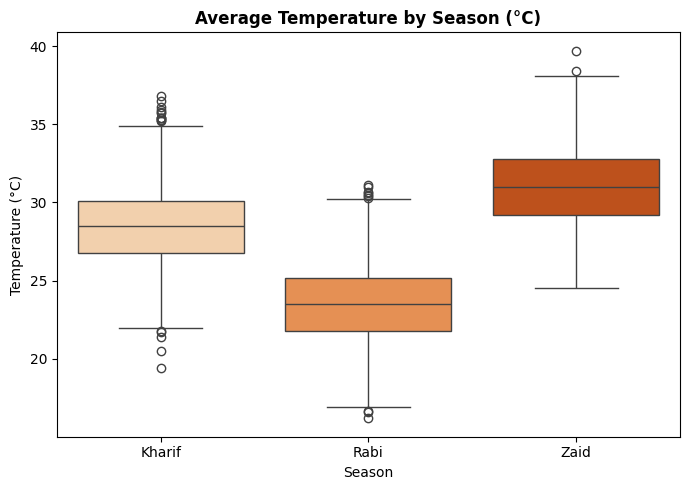

In [155]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Season', y='Avg_Temperature_C', hue='Season', palette='Oranges', legend=False)
plt.title('Average Temperature by Season (°C)', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

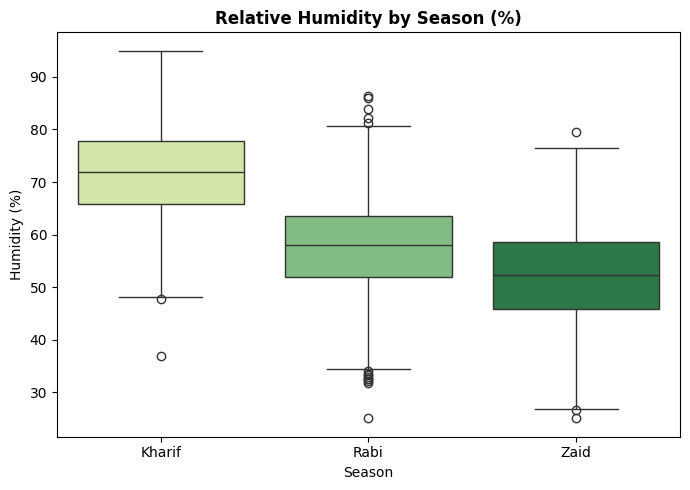

In [156]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Season', y='Humidity_pct', hue='Season', palette='YlGn', legend=False)
plt.title('Relative Humidity by Season (%)', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Humidity (%)')
plt.tight_layout()
plt.show()

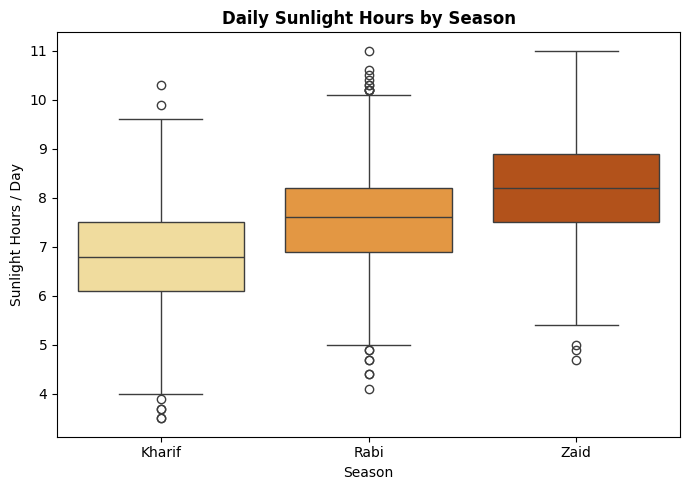

In [157]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Season', y='Sunlight_Hours_Day', hue='Season', palette='YlOrBr', legend=False)
plt.title('Daily Sunlight Hours by Season', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Sunlight Hours / Day')
plt.tight_layout()
plt.show()

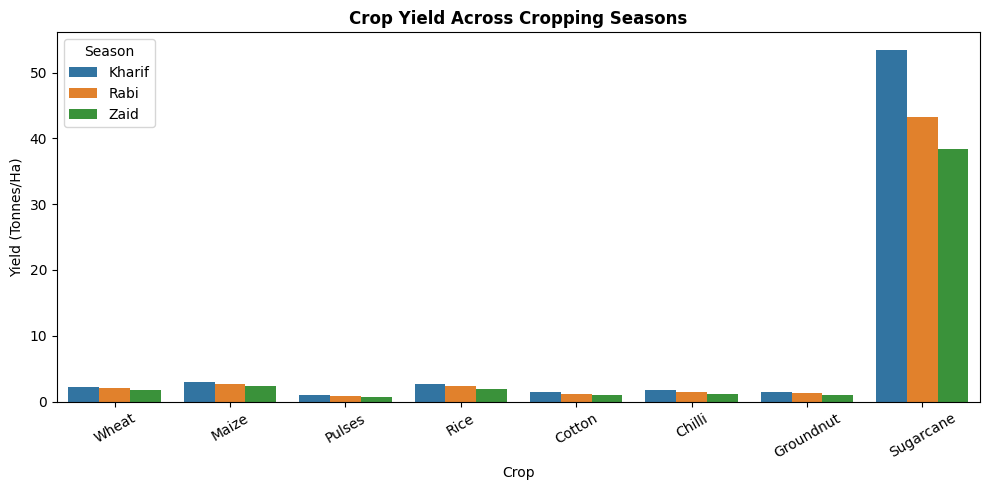

In [158]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_clean, x='Crop', y='Yield_Tonnes_Ha', hue='Season', palette='tab10', errorbar=None)
plt.title('Crop Yield Across Cropping Seasons', fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Yield (Tonnes/Ha)')
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

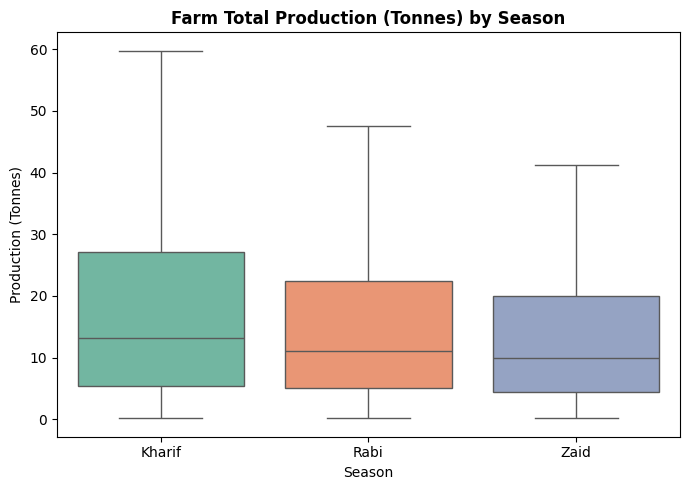

In [159]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Season', y='Production_Tonnes', hue='Season', palette='Set2', showfliers=False, legend=False)
plt.title('Farm Total Production (Tonnes) by Season', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Production (Tonnes)')
plt.tight_layout()
plt.show()

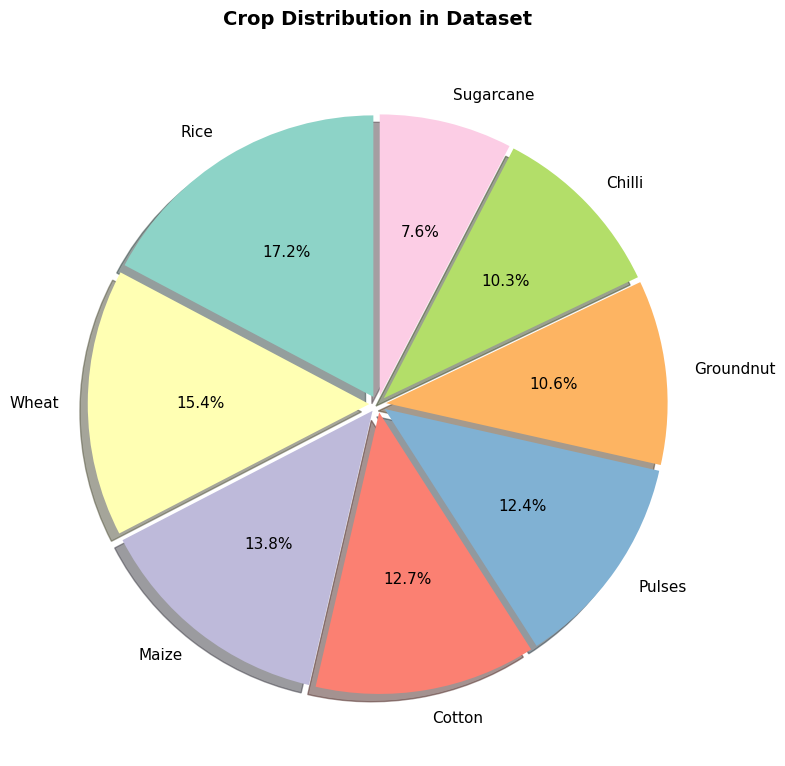

In [160]:
crop_counts = df['Crop'].value_counts()
plt.figure(figsize=(8, 8))
colors_crop = plt.cm.Set3(range(len(crop_counts)))
explode_crop = [0.03] * len(crop_counts)

plt.pie(
    crop_counts.values,
    labels=crop_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_crop,
    explode=explode_crop,
    shadow=True,
    textprops={'fontsize': 11},
)

plt.title('Crop Distribution in Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

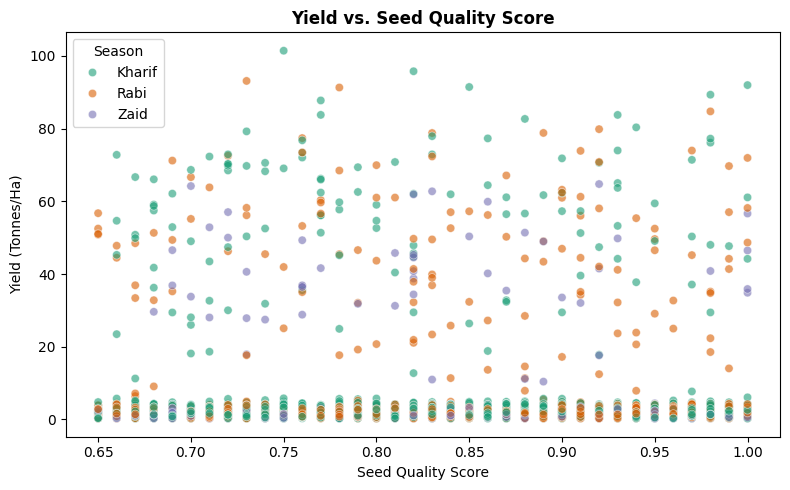

In [161]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Seed_Quality_Score', y='Yield_Tonnes_Ha', hue='Season', alpha=0.6, palette='Dark2')
plt.title('Yield vs. Seed Quality Score', fontweight='bold')
plt.xlabel('Seed Quality Score')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

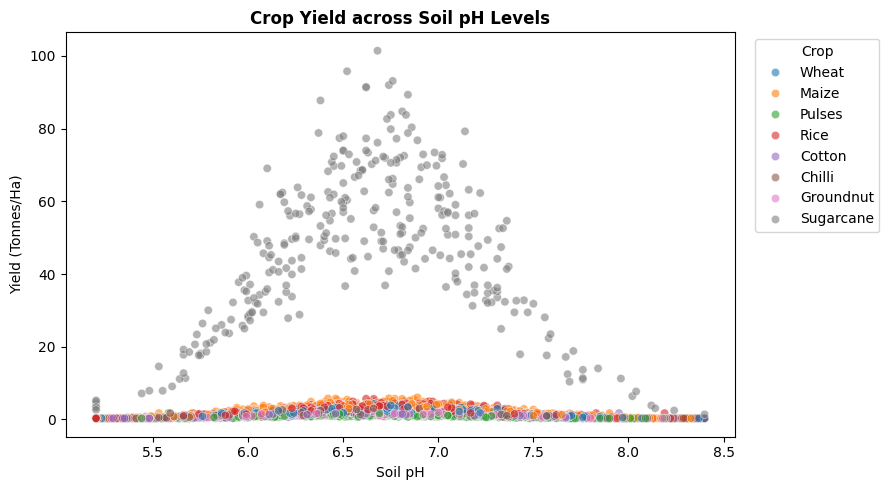

In [162]:
plt.figure(figsize=(9, 5))
sns.scatterplot(data=df_clean, x='Soil_pH', y='Yield_Tonnes_Ha', hue='Crop', alpha=0.6, palette='tab10')
plt.title('Crop Yield across Soil pH Levels', fontweight='bold')
plt.xlabel('Soil pH')
plt.ylabel('Yield (Tonnes/Ha)')
plt.legend(title='Crop', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

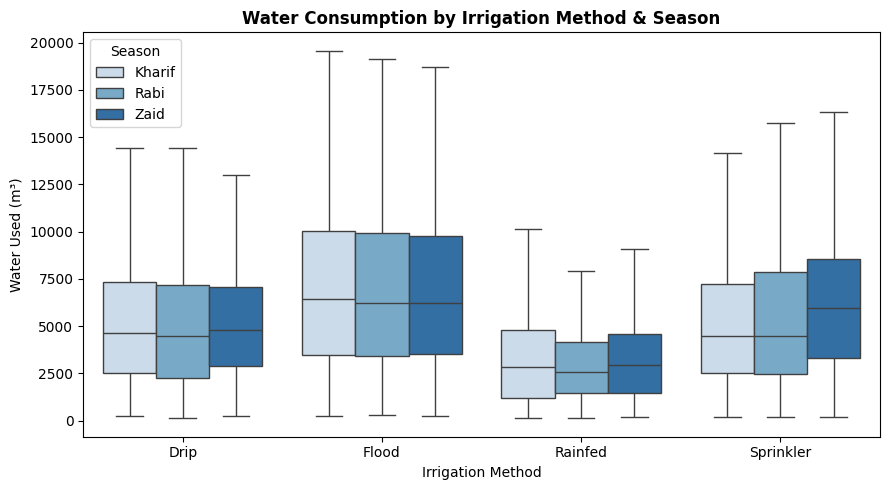

In [163]:
plt.figure(figsize=(9, 5))
sns.boxplot(data=df_clean, x='Irrigation_Method', y='Water_Used_m3', hue='Season', palette='Blues', showfliers=False)
plt.title('Water Consumption by Irrigation Method & Season', fontweight='bold')
plt.xlabel('Irrigation Method')
plt.ylabel('Water Used (m³)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

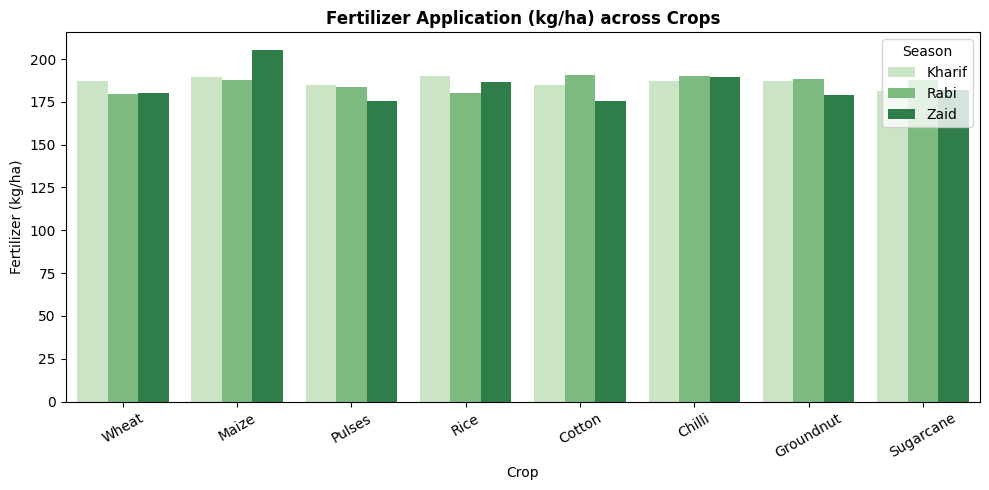

In [164]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_clean, x='Crop', y='Fertilizer_kg_ha', hue='Season', palette='Greens', errorbar=None)
plt.title('Fertilizer Application (kg/ha) across Crops', fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Fertilizer (kg/ha)')
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

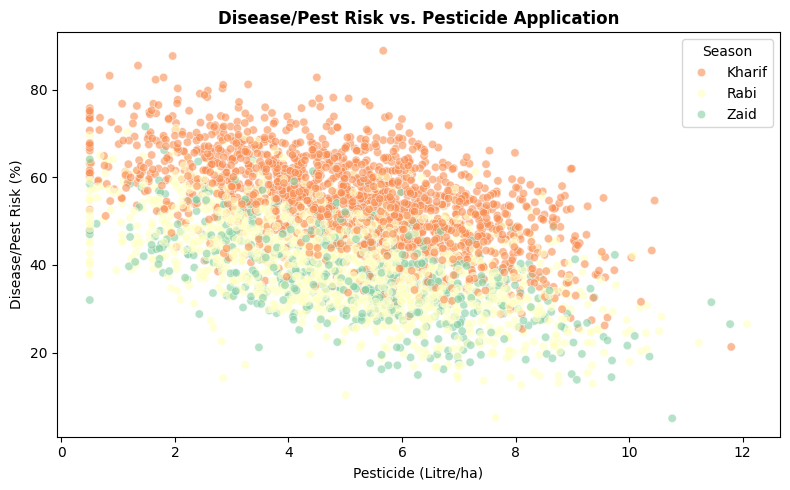

In [165]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_clean, x='Pesticide_Litre_ha', y='Disease_Pest_Risk_pct', hue='Season', alpha=0.6, palette='Spectral')
plt.title('Disease/Pest Risk vs. Pesticide Application', fontweight='bold')
plt.xlabel('Pesticide (Litre/ha)')
plt.ylabel('Disease/Pest Risk (%)')
plt.legend(title='Season')
plt.tight_layout()
plt.show()

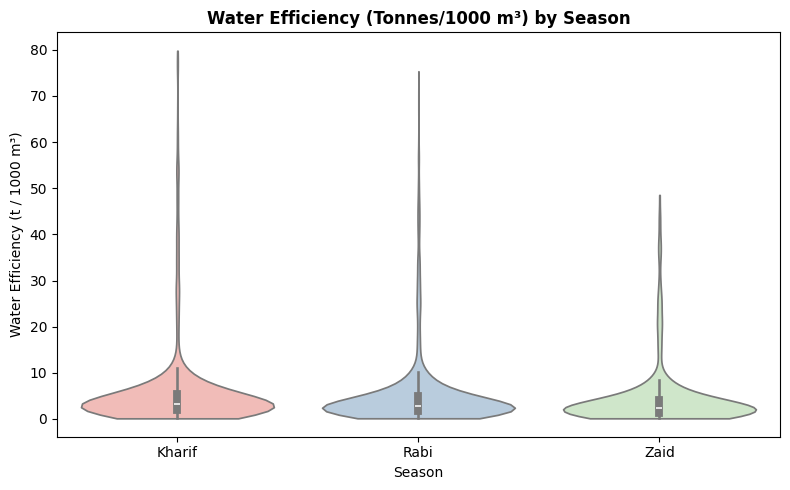

In [166]:
plt.figure(figsize=(8, 5))
sns.violinplot(data=df_clean, x='Season', y='Water_Efficiency_t_per_1000m3', hue='Season', palette='Pastel1', cut=0, legend=False)
plt.title('Water Efficiency (Tonnes/1000 m³) by Season', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Water Efficiency (t / 1000 m³)')
plt.tight_layout()
plt.show()

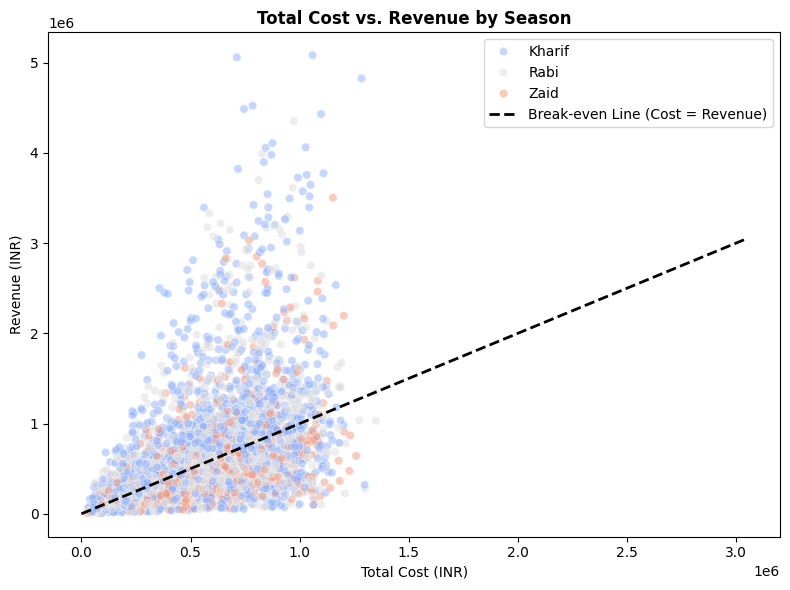

In [167]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_clean, x='Total_Cost_INR', y='Revenue_INR', hue='Season', alpha=0.5, palette='coolwarm')
max_val = max(df_clean['Total_Cost_INR'].max(), df_clean['Revenue_INR'].max())
plt.plot([0, max_val * 0.6], [0, max_val * 0.6], 'k--', lw=2, label='Break-even Line (Cost = Revenue)')
plt.title('Total Cost vs. Revenue by Season', fontweight='bold')
plt.xlabel('Total Cost (INR)')
plt.ylabel('Revenue (INR)')
plt.legend()
plt.tight_layout()
plt.show()

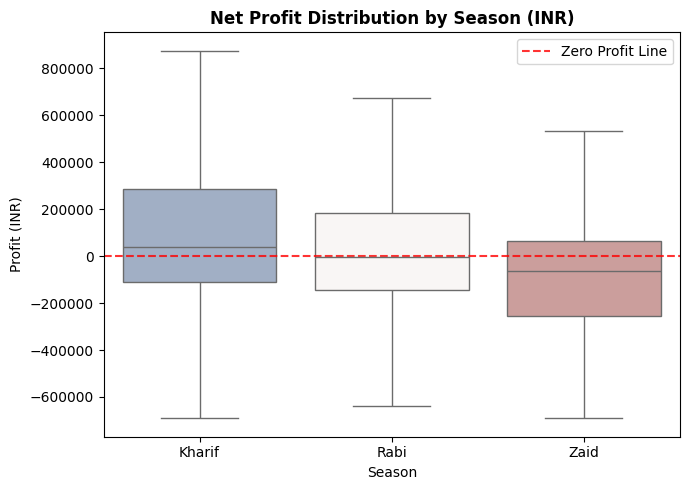

In [168]:
plt.figure(figsize=(7, 5))
sns.boxplot(data=df_clean, x='Season', y='Profit_INR', hue='Season', palette='vlag', showfliers=False, legend=False)
plt.axhline(0, color='red', linestyle='--', alpha=0.8, label='Zero Profit Line')
plt.title('Net Profit Distribution by Season (INR)', fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Profit (INR)')
plt.legend()
plt.tight_layout()
plt.show()

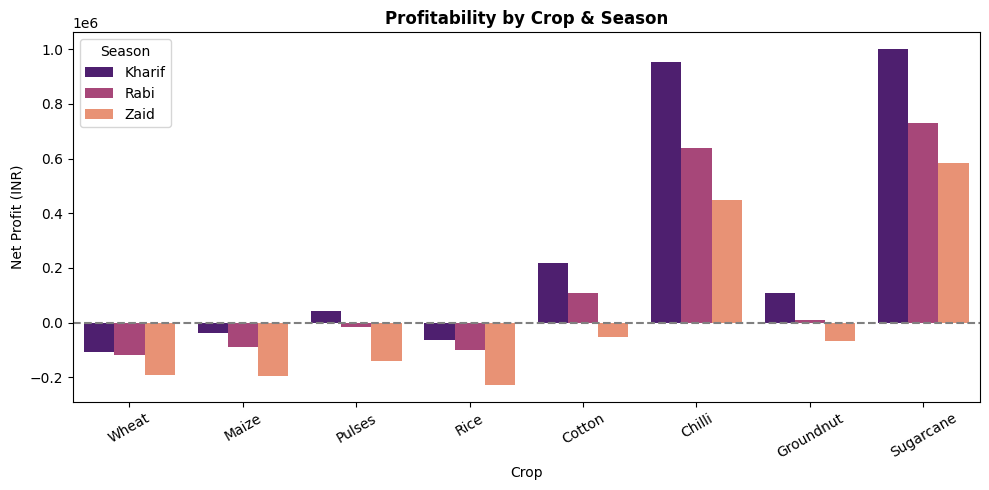

In [169]:
plt.figure(figsize=(10, 5))
sns.barplot(data=df_clean, x='Crop', y='Profit_INR', hue='Season', palette='magma', errorbar=None)
plt.axhline(0, color='gray', linestyle='--')
plt.title('Profitability by Crop & Season', fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Net Profit (INR)')
plt.xticks(rotation=30)
plt.legend(title='Season')
plt.tight_layout()
plt.show()

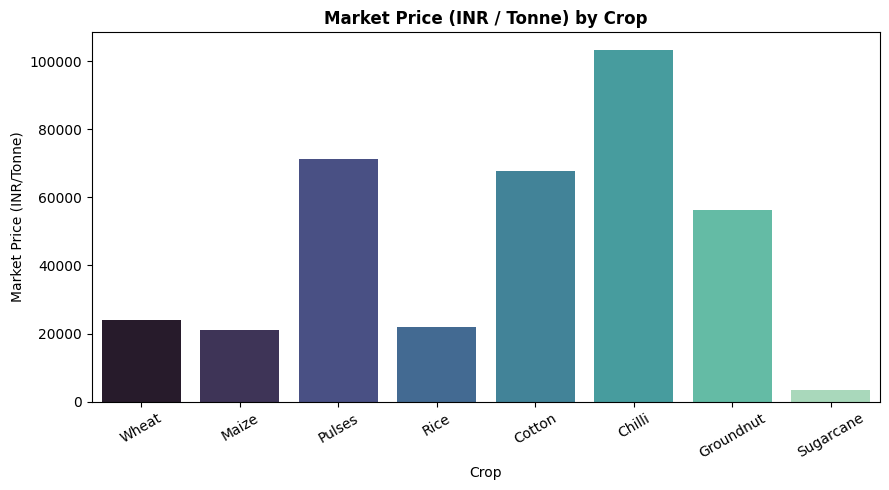

In [170]:
plt.figure(figsize=(9, 5))
sns.barplot(data=df_clean, x='Crop', y='Market_Price_INR_Tonne', hue='Crop', palette='mako', errorbar=None, legend=False)
plt.title('Market Price (INR / Tonne) by Crop', fontweight='bold')
plt.xlabel('Crop')
plt.ylabel('Market Price (INR/Tonne)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

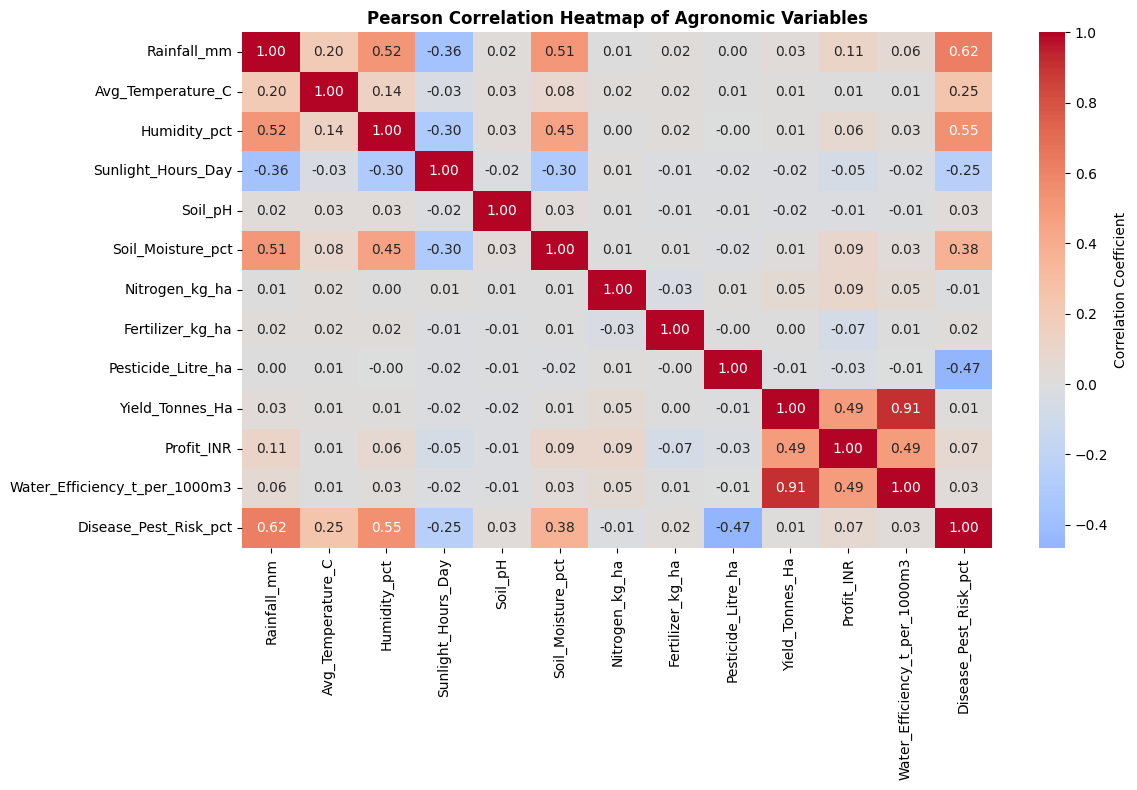

In [171]:
corr_cols = [
    'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct', 'Sunlight_Hours_Day',
    'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha', 'Fertilizer_kg_ha',
    'Pesticide_Litre_ha', 'Yield_Tonnes_Ha', 'Profit_INR', 'Water_Efficiency_t_per_1000m3',
    'Disease_Pest_Risk_pct'
]

plt.figure(figsize=(12, 8))
sns.heatmap(df_clean[corr_cols].corr(), annot=True, fmt=".2f", cmap="coolwarm", center=0, cbar_kws={'label': 'Correlation Coefficient'})
plt.title('Pearson Correlation Heatmap of Agronomic Variables', fontweight='bold')
plt.tight_layout()
plt.show()

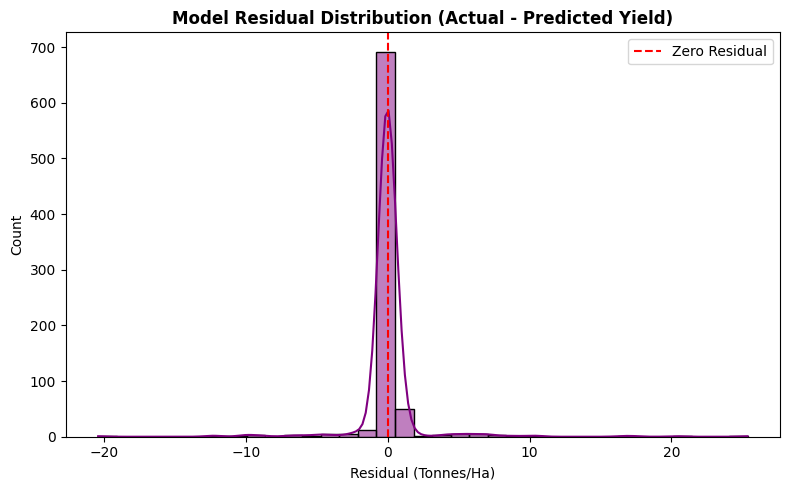

In [172]:
features = [
    'Season', 'Crop', 'State', 'Irrigation_Method',
    'Farm_Area_Hectares', 'Rainfall_mm', 'Avg_Temperature_C', 'Humidity_pct',
    'Sunlight_Hours_Day', 'Soil_pH', 'Soil_Moisture_pct', 'Nitrogen_kg_ha',
    'Phosphorus_kg_ha', 'Potassium_kg_ha', 'Fertilizer_kg_ha',
    'Pesticide_Litre_ha', 'Seed_Quality_Score', 'Water_Used_m3', 'Disease_Pest_Risk_pct'
]
cat_cols = ['Season', 'Crop', 'State', 'Irrigation_Method']
num_cols = [c for c in features if c not in cat_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(df_clean[features], df_clean['Yield_Tonnes_Ha'], test_size=0.2, random_state=42)
pipe = Pipeline([('prep', preprocessor), ('reg', GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5))])
pipe.fit(X_train, y_train)

residuals = y_test - pipe.predict(X_test)

plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, color='purple', bins=35)
plt.axvline(0, color='red', linestyle='--', label='Zero Residual')
plt.title('Model Residual Distribution (Actual - Predicted Yield)', fontweight='bold')
plt.xlabel('Residual (Tonnes/Ha)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

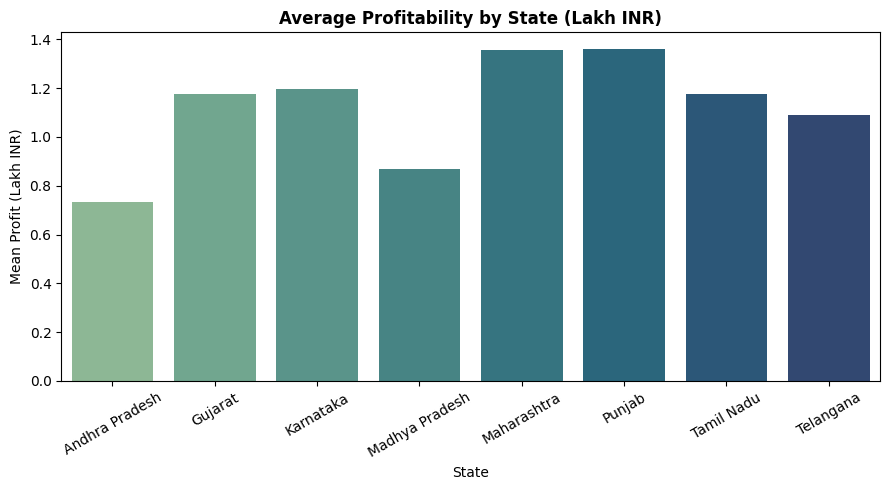

In [173]:
state_perf = df_clean.groupby('State')['Profit_INR'].mean().reset_index()
state_perf['Profit_Lakhs'] = state_perf['Profit_INR'] / 100000

plt.figure(figsize=(9, 5))
sns.barplot(data=state_perf, x='State', y='Profit_Lakhs', hue='State', palette='crest', legend=False)
plt.title('Average Profitability by State (Lakh INR)', fontweight='bold')
plt.xlabel('State')
plt.ylabel('Mean Profit (Lakh INR)')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()